Initializing NUTS using jitter+adapt_diag...
/home/gfertt/.local/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sequential sampling (4 chains in 1 job)
NUTS: [weights, mus, sigmas, sigma_noise]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 474 seconds.


--- Model Summary ---
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mus[0]       0.552  0.064   0.449    0.665      0.002    0.001    1298.0   
mus[1]       2.115  0.349   1.510    2.787      0.010    0.008    1350.0   
sigmas[0]    0.150  0.074   0.006    0.264      0.002    0.001    1322.0   
sigmas[1]    0.502  0.266   0.003    0.884      0.005    0.003    2440.0   
weights[0]   0.637  0.090   0.476    0.804      0.003    0.001    1274.0   
weights[1]   0.363  0.090   0.196    0.524      0.003    0.001    1274.0   
sigma_noise  0.009  0.001   0.008    0.010      0.000    0.000    3011.0   

             ess_tail  r_hat  
mus[0]         2331.0    1.0  
mus[1]         2064.0    1.0  
sigmas[0]      1723.0    1.0  
sigmas[1]      1980.0    1.0  
weights[0]     1938.0    1.0  
weights[1]     1938.0    1.0  
sigma_noise    3217.0    1.0  

--- Plotting Results ---


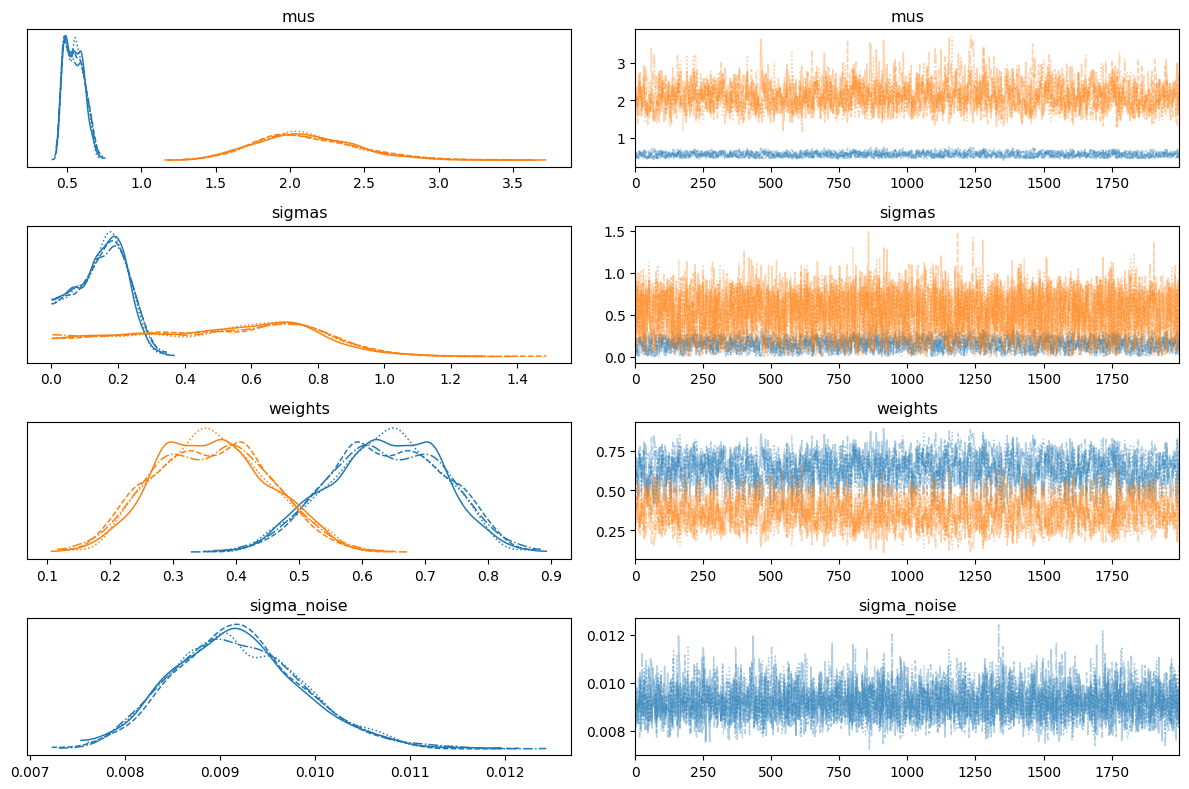

/tmp/ipykernel_1045/1118077094.py:107: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  post_pred = pm.sample_posterior_predictive(idata, var_names=["Y_obs"], random_seed=42)
Sampling: [Y_obs]


Output()

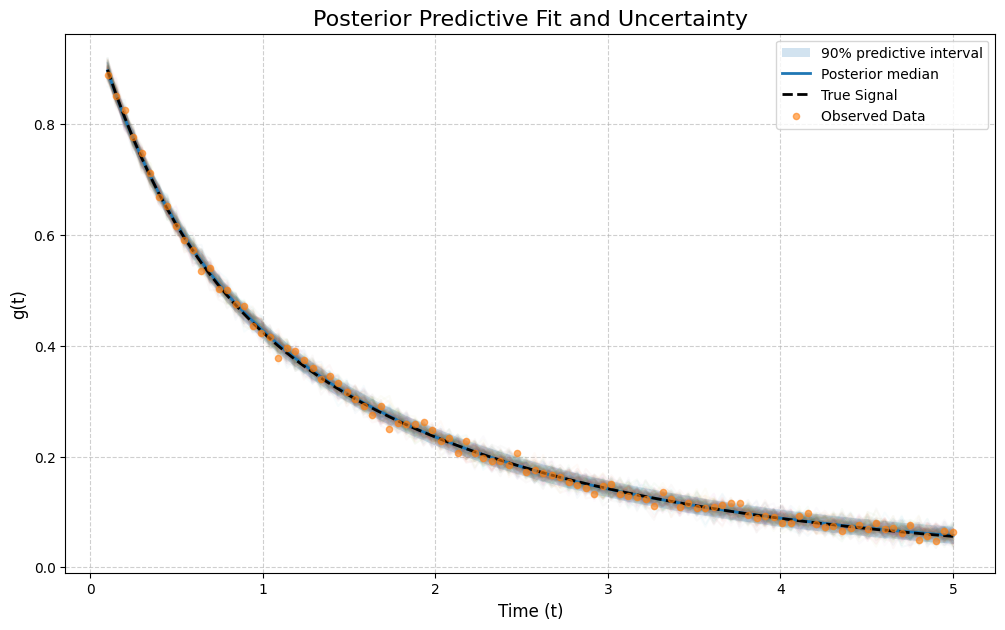

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from pytensor.tensor import erfc as pt_erfc
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import erfc as np_erfc

# -----------------------------
# 1) PyTensor forward model
# -----------------------------
def laplace_transform_of_gmm(mus, sigmas, weights, t):
    """
    Vectorized Laplace transform of a Gaussian Mixture Model in PyTensor.
    mus, sigmas, weights: shape (K,)
    t: shape (T,)
    returns: shape (T,)
    """
    t = pt.as_tensor_variable(t)           # (T,)
    mus = pt.as_tensor_variable(mus)       # (K,)
    sigmas = pt.as_tensor_variable(sigmas) # (K,)
    weights = pt.as_tensor_variable(weights) # (K,)

    # Broadcast to (K, T)
    t_bt = t[None, :]              # (1, T)
    mus_bt = mus[:, None]          # (K, 1)
    sigmas_bt = sigmas[:, None]    # (K, 1)
    weights_bt = weights[:, None]  # (K, 1)

    arg = (sigmas_bt**2 * t_bt - mus_bt) / (pt.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * pt.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * pt_erfc(arg)
    # Weighted sum across K
    result = pt.sum(weights_bt * comp, axis=0)  # (T,)
    return result

# -----------------------------
# 2) Synthetic data
# -----------------------------
TRUE_MUS = np.array([0.5, 2.0])
TRUE_SIGMAS = np.array([0.1, 0.4])
TRUE_WEIGHTS = np.array([0.6, 0.4])
TRUE_NOISE_SD = 0.01
K = len(TRUE_MUS)

t_data_np = np.linspace(0.1, 5, 100)

def laplace_transform_numpy(mus, sigmas, weights, t):
    mus = np.asarray(mus); sigmas = np.asarray(sigmas); weights = np.asarray(weights); t = np.asarray(t)
    # Vectorized NumPy version for data gen
    t_bt = t[None, :]               # (1, T)
    mus_bt = mus[:, None]           # (K, 1)
    sigmas_bt = sigmas[:, None]     # (K, 1)
    weights_bt = weights[:, None]   # (K, 1)
    arg = (sigmas_bt**2 * t_bt - mus_bt) / (np.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * np.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * np_erfc(arg)
    return np.sum(weights_bt * comp, axis=0)

rng = np.random.default_rng(123)
true_signal = laplace_transform_numpy(TRUE_MUS, TRUE_SIGMAS, TRUE_WEIGHTS, t_data_np)
observed_data = true_signal + rng.normal(0, TRUE_NOISE_SD, size=t_data_np.size)

# -----------------------------
# 3) PyMC model
# -----------------------------
with pm.Model() as model:
    # Time points as shared tensor
    t_data = pm.Data("t_data", t_data_np)

    # Priors
    weights = pm.Dirichlet("weights", a=np.ones(K))
    mus = pm.Normal("mus", mu=1.0, sigma=2.0, shape=K)
    sigmas = pm.HalfNormal("sigmas", sigma=1.0, shape=K)
    sigma_noise = pm.HalfNormal("sigma_noise", sigma=0.1)

    # Label-ordering to reduce label switching
    pm.Potential("order_means_potential", pt.switch(mus[1] > mus[0], 0.0, -np.inf))

    # Forward model
    g_predicted = laplace_transform_of_gmm(mus, sigmas, weights, t_data)
    pm.Deterministic("g_predicted", g_predicted)

    # Likelihood
    Y_obs = pm.Normal("Y_obs", mu=g_predicted, sigma=sigma_noise, observed=observed_data)

# -----------------------------
# 4) Sampling
# -----------------------------
with model:
    idata = pm.sample(
        draws=2000, tune=1000, chains=4, cores=1, random_seed=42, target_accept=0.9
    )

# -----------------------------
# 5) Summary & diagnostics
# -----------------------------
print("--- Model Summary ---")
summary = az.summary(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
print(summary)

print("\n--- Plotting Results ---")
az.plot_trace(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
plt.tight_layout()
plt.show()

# Posterior predictive
with model:
    post_pred = pm.sample_posterior_predictive(idata, var_names=["Y_obs"], random_seed=42)

# post_pred.posterior_predictive["Y_obs"] is xarray: (chain, draw, time)
y_pp = post_pred.posterior_predictive["Y_obs"].values  # shape (C, D, T)
y_pp_flat = y_pp.reshape(-1, y_pp.shape[-1])           # (C*D, T)

# Credible band & median
q05, q50, q95 = np.percentile(y_pp_flat, [5, 50, 95], axis=0)

plt.figure(figsize=(12, 7))
# plot a thin cloud of random posterior draws
idx = rng.choice(y_pp_flat.shape[0], size=min(200, y_pp_flat.shape[0]), replace=False)
for i in idx:
    plt.plot(t_data_np, y_pp_flat[i], alpha=0.03)

plt.fill_between(t_data_np, q05, q95, alpha=0.2, label="90% predictive interval")
plt.plot(t_data_np, q50, label="Posterior median", linewidth=2)

# Truth & data
plt.plot(t_data_np, true_signal, label="True Signal", color="black", linestyle="--", linewidth=2)
plt.scatter(t_data_np, observed_data, label="Observed Data", alpha=0.6, s=20, zorder=5)

plt.title("Posterior Predictive Fit and Uncertainty", fontsize=16)
plt.xlabel("Time (t)", fontsize=12)
plt.ylabel("g(t)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


/home/gfertt/.local/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
/home/gfertt/.local/lib/python3.10/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of

--- Model Summary ---
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mus[0]       0.553  0.065   0.451    0.669      0.002    0.001    1286.0   
mus[1]       2.124  0.353   1.491    2.803      0.010    0.005    1296.0   
sigmas[0]    0.151  0.076   0.003    0.265      0.002    0.001    1256.0   
sigmas[1]    0.492  0.273   0.000    0.873      0.006    0.003    1815.0   
weights[0]   0.640  0.092   0.473    0.804      0.003    0.001    1222.0   
weights[1]   0.360  0.092   0.196    0.527      0.003    0.001    1222.0   
sigma_noise  0.009  0.001   0.008    0.010      0.000    0.000    3446.0   

             ess_tail  r_hat  
mus[0]         2757.0    1.0  
mus[1]         2548.0    1.0  
sigmas[0]      1556.0    1.0  
sigmas[1]      1484.0    1.0  
weights[0]     2600.0    1.0  
weights[1]     2600.0    1.0  
sigma_noise    3703.0    1.0  

--- Plotting Results ---


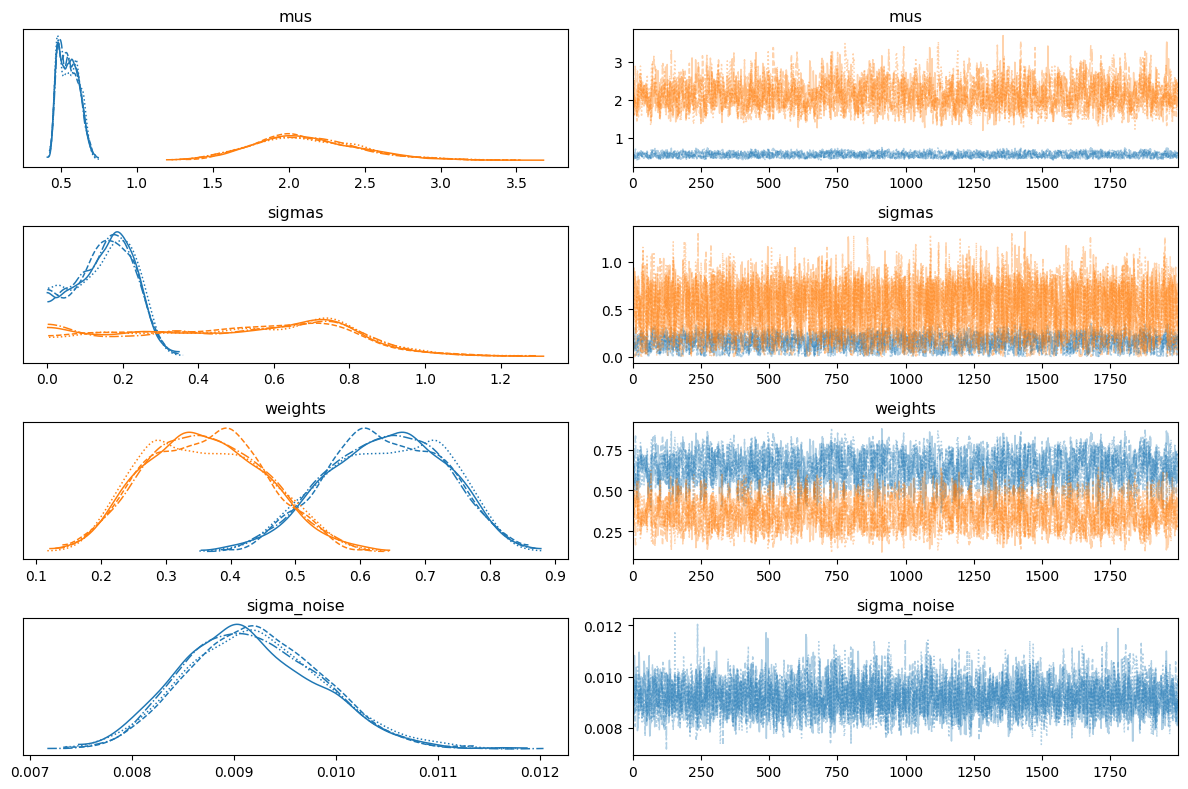

/tmp/ipykernel_13897/4183874957.py:116: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  post_pred = pm.sample_posterior_predictive(idata, var_names=["Y_obs"], random_seed=42)
Sampling: [Y_obs]


Output()

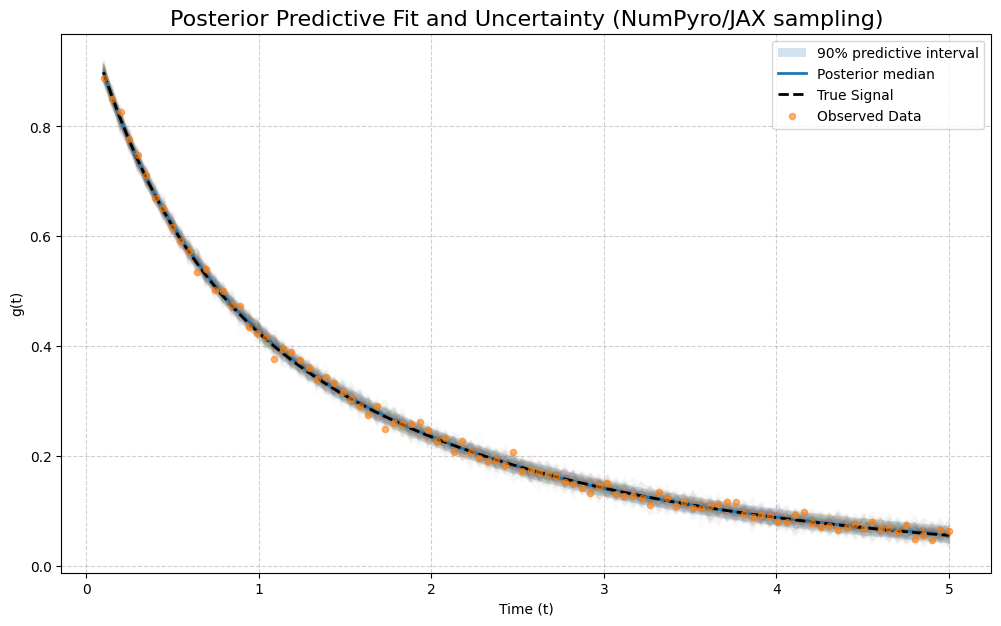

In [2]:
import numpy as np
import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
from pytensor.tensor import erfc as pt_erfc
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import erfc as np_erfc
import jax
jax.config.update("jax_enable_x64", True)

# -----------------------------
# 1) PyTensor forward model
# -----------------------------
def laplace_transform_of_gmm(mus, sigmas, weights, t):
    """
    Vectorized Laplace transform of a Gaussian Mixture Model in PyTensor.
    mus, sigmas, weights: shape (K,)
    t: shape (T,)
    returns: shape (T,)
    """
    t = pt.as_tensor_variable(t)           # (T,)
    mus = pt.as_tensor_variable(mus)       # (K,)
    sigmas = pt.as_tensor_variable(sigmas) # (K,)
    weights = pt.as_tensor_variable(weights) # (K,)

    # Broadcast to (K, T)
    t_bt = t[None, :]              # (1, T)
    mus_bt = mus[:, None]          # (K, 1)
    sigmas_bt = sigmas[:, None]    # (K, 1)
    weights_bt = weights[:, None]  # (K, 1)

    arg = (sigmas_bt**2 * t_bt - mus_bt) / (pt.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * pt.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * pt_erfc(arg)
    result = pt.sum(weights_bt * comp, axis=0)  # (T,)
    return result

# -----------------------------
# 2) Synthetic data
# -----------------------------
TRUE_MUS = np.array([0.5, 2.0])
TRUE_SIGMAS = np.array([0.1, 0.4])
TRUE_WEIGHTS = np.array([0.6, 0.4])
TRUE_NOISE_SD = 0.01
K = len(TRUE_MUS)

t_data_np = np.linspace(0.1, 5, 100)

def laplace_transform_numpy(mus, sigmas, weights, t):
    mus = np.asarray(mus); sigmas = np.asarray(sigmas); weights = np.asarray(weights); t = np.asarray(t)
    t_bt = t[None, :]
    mus_bt = mus[:, None]
    sigmas_bt = sigmas[:, None]
    weights_bt = weights[:, None]
    arg = (sigmas_bt**2 * t_bt - mus_bt) / (np.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * np.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * np_erfc(arg)
    return np.sum(weights_bt * comp, axis=0)

rng = np.random.default_rng(123)
true_signal = laplace_transform_numpy(TRUE_MUS, TRUE_SIGMAS, TRUE_WEIGHTS, t_data_np)
observed_data = true_signal + rng.normal(0, TRUE_NOISE_SD, size=t_data_np.size)

# -----------------------------
# 3) PyMC model
# -----------------------------
with pm.Model() as model:
    t_data = pm.Data("t_data", t_data_np)

    weights = pm.Dirichlet("weights", a=np.ones(K))
    mus = pm.Normal("mus", mu=1.0, sigma=2.0, shape=K)
    sigmas = pm.HalfNormal("sigmas", sigma=1.0, shape=K)
    sigma_noise = pm.HalfNormal("sigma_noise", sigma=0.1)

    # Reduce label switching
    pm.Potential("order_means_potential", pt.switch(mus[1] > mus[0], 0.0, -np.inf))

    g_predicted = laplace_transform_of_gmm(mus, sigmas, weights, t_data)
    pm.Deterministic("g_predicted", g_predicted)

    Y_obs = pm.Normal("Y_obs", mu=g_predicted, sigma=sigma_noise, observed=observed_data)

# -----------------------------
# 4) JAX/NumPyro sampling
# -----------------------------
with model:
    idata = pmjax.sample_numpyro_nuts(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        chain_method="parallel",   # "sequential" if you want to see logs in one process
    )

# -----------------------------
# 5) Summary & diagnostics
# -----------------------------
print("--- Model Summary ---")
summary = az.summary(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
print(summary)

print("\n--- Plotting Results ---")
az.plot_trace(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Posterior predictive using JAX backend (fallback to PyMC if needed)
# -----------------------------
try:
    with model:
        post_pred = pmjax.sample_posterior_predictive(idata, var_names=["Y_obs"], random_seed=42)
except AttributeError:
    # Older PyMC versions: use standard PPC (works fine with JAX-sampled posterior)
    with model:
        post_pred = pm.sample_posterior_predictive(idata, var_names=["Y_obs"], random_seed=42)

y_pp = post_pred.posterior_predictive["Y_obs"].values  # (chain, draw, T)
y_pp_flat = y_pp.reshape(-1, y_pp.shape[-1])
q05, q50, q95 = np.percentile(y_pp_flat, [5, 50, 95], axis=0)

plt.figure(figsize=(12, 7))
idx = rng.choice(y_pp_flat.shape[0], size=min(200, y_pp_flat.shape[0]), replace=False)
for i in idx:
    plt.plot(t_data_np, y_pp_flat[i], alpha=0.03)

plt.fill_between(t_data_np, q05, q95, alpha=0.2, label="90% predictive interval")
plt.plot(t_data_np, q50, label="Posterior median", linewidth=2)

plt.plot(t_data_np, true_signal, label="True Signal", color="black", linestyle="--", linewidth=2)
plt.scatter(t_data_np, observed_data, label="Observed Data", alpha=0.6, s=20, zorder=5)

plt.title("Posterior Predictive Fit and Uncertainty (NumPyro/JAX sampling)", fontsize=16)
plt.xlabel("Time (t)")
plt.ylabel("g(t)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [3]:
"""
--- Model Summary ---
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mus[0]       0.553  0.065   0.451    0.669      0.002    0.001    1286.0   
mus[1]       2.124  0.353   1.491    2.803      0.010    0.005    1296.0   
sigmas[0]    0.151  0.076   0.003    0.265      0.002    0.001    1256.0   
sigmas[1]    0.492  0.273   0.000    0.873      0.006    0.003    1815.0   
weights[0]   0.640  0.092   0.473    0.804      0.003    0.001    1222.0   
weights[1]   0.360  0.092   0.196    0.527      0.003    0.001    1222.0   
sigma_noise  0.009  0.001   0.008    0.010      0.000    0.000    3446.0   

             ess_tail  r_hat  
mus[0]         2757.0    1.0  
mus[1]         2548.0    1.0  
sigmas[0]      1556.0    1.0  
sigmas[1]      1484.0    1.0  
weights[0]     2600.0    1.0  
weights[1]     2600.0    1.0  
sigma_noise    3703.0    1.0  
"""
TRUE_MUS, TRUE_SIGMAS, TRUE_WEIGHTS, TRUE_NOISE_SD

(array([0.5, 2. ]), array([0.1, 0.4]), array([0.6, 0.4]), 0.01)

In [ ]:
"""
NumPyro translation of the PyMC model with corrected broadcasting for Predictive.
Key fix: make `t` broadcast across arbitrary leading batch dims (chains, draws)
by reshaping it to (..., 1, T) where `...` matches the sample batch shape and
`1` aligns with the mixture component axis K. This avoids errors like
`ValueError: Incompatible shapes for broadcasting: shapes=[(20, 1, 2), (1, 100)]`.
"""

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax.scipy.special import erfc as jax_erfc

import numpyro
import numpyro.distributions as dist
from numpyro import deterministic, factor, sample
from numpyro.infer import MCMC, NUTS, Predictive

from scipy.special import erfc as np_erfc

# Optional: better numerical agreement with NumPy/SciPy
# jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", "cpu")
print("JAX devices:", jax.devices())

# -----------------------------
# 1) JAX forward model (with robust broadcasting)
# -----------------------------

def laplace_transform_jax(mus, sigmas, weights, t):
    """
    Vectorized Laplace transform of a Gaussian Mixture Model using JAX.

    Supports inputs with arbitrary leading batch dimensions. In Predictive,
    (mus, sigmas, weights) typically have shape (chains, draws, K). This
    function reshapes `t` so broadcasting works cleanly against those dims.

    Parameters
    ----------
    mus, sigmas, weights : jnp.ndarray, shape (..., K)
    t : jnp.ndarray, shape (T,)

    Returns
    -------
    jnp.ndarray, shape (..., T)
    """
    t = jnp.asarray(t)             # (T,)
    mus = jnp.asarray(mus)         # (..., K)
    sigmas = jnp.asarray(sigmas)   # (..., K)
    weights = jnp.asarray(weights) # (..., K)

    # Leading batch rank (e.g., chains, draws)
    lead_rank = mus.ndim - 1  # exclude the K axis

    # Shape t to (..., 1, T): add `lead_rank` singleton dims, then a singleton for K
    t_lead = jnp.reshape(t, (1,) * lead_rank + (t.shape[0],))   # (..., T)
    t_bt = t_lead[..., None, :]                                 # (..., 1, T)

    # Shape params to (..., K, 1)
    mus_bt = mus[..., None]           # (..., K, 1)
    sigmas_bt = sigmas[..., None]     # (..., K, 1)
    weights_bt = weights[..., None]   # (..., K, 1)

    arg = (sigmas_bt**2 * t_bt - mus_bt) / (jnp.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * jnp.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * jax_erfc(arg)
    return jnp.sum(weights_bt * comp, axis=-2)  # sum over K → shape (..., T)

# -----------------------------
# 2) Synthetic data (NumPy)
# -----------------------------
TRUE_MUS = np.array([0.5, 2.0])
TRUE_SIGMAS = np.array([0.1, 0.4])
TRUE_WEIGHTS = np.array([0.6, 0.4])
TRUE_NOISE_SD = 0.01
K = len(TRUE_MUS)

t_data_np = np.linspace(0.1, 5, 100)


def laplace_transform_numpy(mus, sigmas, weights, t):
    mus = np.asarray(mus)
    sigmas = np.asarray(sigmas)
    weights = np.asarray(weights)
    t = np.asarray(t)
    t_bt = t[None, :]
    mus_bt = mus[:, None]
    sigmas_bt = sigmas[:, None]
    weights_bt = weights[:, None]
    arg = (sigmas_bt**2 * t_bt - mus_bt) / (np.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * np.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * np_erfc(arg)
    return np.sum(weights_bt * comp, axis=0)

rng_np = np.random.default_rng(123)
true_signal = laplace_transform_numpy(TRUE_MUS, TRUE_SIGMAS, TRUE_WEIGHTS, t_data_np)
observed_data = true_signal + rng_np.normal(0, TRUE_NOISE_SD, size=t_data_np.size)

# -----------------------------
# 3) NumPyro model
# -----------------------------

def model(t, y=None, K=2):
    # Priors
    weights = sample("weights", dist.Dirichlet(jnp.ones(K)))
    mus = sample("mus", dist.Normal(1.0, 2.0).expand([K]).to_event(1))
    sigmas = sample("sigmas", dist.HalfNormal(1.0).expand([K]).to_event(1))
    sigma_noise = sample("sigma_noise", dist.HalfNormal(0.1))

    # Label-ordering to reduce label switching (strictly increasing mus)
    ok = jnp.all(jnp.diff(mus, axis=-1) > 0.0, axis=-1)
    factor("order_mus_factor", jnp.where(ok, 0.0, -jnp.inf))

    # Forward model
    g_predicted = laplace_transform_jax(mus, sigmas, weights, t)
    deterministic("g_predicted", g_predicted)

    # Likelihood
    sample("Y_obs", dist.Normal(g_predicted, sigma_noise), obs=y)

# -----------------------------
# 4) Sampling (NUTS)
# -----------------------------

t_data_jnp = jnp.asarray(t_data_np)
rng_key = jax.random.PRNGKey(42)

nuts = NUTS(model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_warmup=100, num_samples=200, num_chains=1)
mcmc.run(rng_key, t=t_data_jnp, y=jnp.asarray(observed_data), K=K)
mcmc.print_summary()

# -----------------------------
# 5) Summary & diagnostics with ArviZ
# -----------------------------
posterior_samples = mcmc.get_samples(group_by_chain=True)  # shapes (C, D, ...)

# Posterior predictive (also returns deterministic g_predicted)
pred = Predictive(
    model,
    posterior_samples=posterior_samples,
    return_sites=["Y_obs", "g_predicted"],
)
ppc = pred(rng_key, t=t_data_jnp, y=None, K=K)

# Build InferenceData for nice summaries/plots
coords = {"time": t_data_np, "component": np.arange(K)}
dims = {
    "Y_obs": ["time"],
    "g_predicted": ["time"],
    "mus": ["component"],
    "sigmas": ["component"],
    "weights": ["component"],
}

idata = az.from_numpyro(
    mcmc,
    posterior_predictive={"Y_obs": ppc["Y_obs"]},
    predictions={"g_predicted": ppc["g_predicted"]},
    coords=coords,
    dims=dims,
)

print("\n--- Model Summary ---")
summary = az.summary(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
print(summary)

print("\n--- Plotting Results ---")
az.plot_trace(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Posterior predictive plot (median + 90% band)
# -----------------------------
y_pp = np.asarray(ppc["Y_obs"])            # shape (C, D, T)
y_pp_flat = y_pp.reshape(-1, y_pp.shape[-1])  # (C*D, T)

q05, q50, q95 = np.percentile(y_pp_flat, [5, 50, 95], axis=0)

rng_np2 = np.random.default_rng(1234)
plt.figure(figsize=(12, 7))

idx = rng_np2.choice(y_pp_flat.shape[0], size=min(200, y_pp_flat.shape[0]), replace=False)
for i in idx:
    plt.plot(t_data_np, y_pp_flat[i], alpha=0.03)

plt.fill_between(t_data_np, q05, q95, alpha=0.2, label="90% predictive interval")
plt.plot(t_data_np, q50, label="Posterior median", linewidth=2)

# Truth & data
plt.plot(t_data_np, true_signal, label="True Signal", color="black", linestyle="--", linewidth=2)
plt.scatter(t_data_np, observed_data, label="Observed Data", alpha=0.6, s=20, zorder=5)

plt.title("Posterior Predictive Fit and Uncertainty (NumPyro)", fontsize=16)
plt.xlabel("Time (t)", fontsize=12)
plt.ylabel("g(t)", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
``

JAX devices: [CpuDevice(id=0)]


sample: 100%|██████████| 300/300 [00:04<00:00, 71.33it/s, 255 steps of size 1.08e-02. acc. prob=0.96] 



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
       mus[0]      0.55      0.07      0.55      0.44      0.65     20.97      1.04
       mus[1]      2.09      0.38      2.08      1.51      2.58     24.82      1.08
  sigma_noise      0.01      0.00      0.01      0.01      0.01     72.67      1.00
    sigmas[0]      0.15      0.08      0.16      0.00      0.25     15.74      1.04
    sigmas[1]      0.54      0.28      0.61      0.06      0.90     21.79      1.03
   weights[0]      0.63      0.10      0.64      0.46      0.78     18.94      1.07
   weights[1]      0.37      0.10      0.36      0.22      0.54     18.94      1.07

Number of divergences: 0


ValueError: Incompatible shapes for broadcasting: shapes=[(), (200, 100), (200,)]

/tmp/ipykernel_24360/2370933572.py:102: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=4)
sample: 100%|██████████| 3000/3000 [00:09<00:00, 305.93it/s, 127 steps of size 2.05e-02. acc. prob=0.93]


{'Y_obs': (4, 2000, 100), 'g_predicted': (4, 2000, 100)}


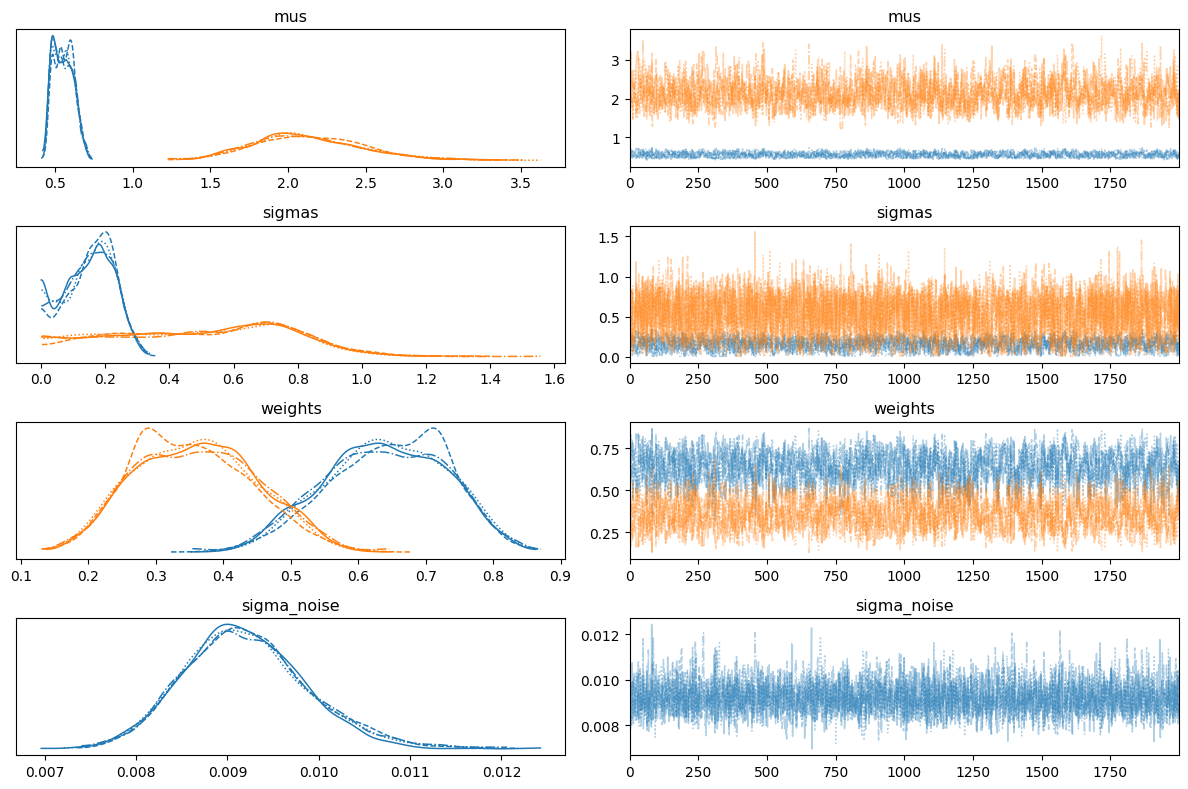

In [3]:
# Minimal fix for your error: make `sigma_noise` broadcast over time in the likelihood.
# The issue arises in Predictive where g_predicted has shape (batch, T)
# while sigma_noise has shape (batch,). Expanding sigma_noise to (batch, 1)
# resolves the mismatch.

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax.scipy.special import erfc as jax_erfc

import numpyro
import numpyro.distributions as dist
from numpyro import deterministic, factor, sample
from numpyro.infer import MCMC, NUTS, Predictive

from scipy.special import erfc as np_erfc

jax.config.update("jax_platforms", "cpu")

# -----------------------------
# 1) JAX forward model (robust broadcasting)
# -----------------------------

def laplace_transform_jax(mus, sigmas, weights, t):
    t = jnp.asarray(t)             # (T,)
    mus = jnp.asarray(mus)         # (..., K)
    sigmas = jnp.asarray(sigmas)   # (..., K)
    weights = jnp.asarray(weights) # (..., K)

    lead_rank = mus.ndim - 1
    t_bt = jnp.reshape(t, (1,) * lead_rank + (t.shape[0],))  # (..., T)
    t_bt = t_bt[..., None, :]                                # (..., 1, T)

    mus_bt = mus[..., None]           # (..., K, 1)
    sigmas_bt = sigmas[..., None]     # (..., K, 1)
    weights_bt = weights[..., None]   # (..., K, 1)

    arg = (sigmas_bt**2 * t_bt - mus_bt) / (jnp.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * jnp.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * jax_erfc(arg)
    return jnp.sum(weights_bt * comp, axis=-2)  # (..., T)

# -----------------------------
# 2) Synthetic data
# -----------------------------
TRUE_MUS = np.array([0.5, 2.0])
TRUE_SIGMAS = np.array([0.1, 0.4])
TRUE_WEIGHTS = np.array([0.6, 0.4])
TRUE_NOISE_SD = 0.01
K = len(TRUE_MUS)

t_data_np = np.linspace(0.1, 5, 100)


def laplace_transform_numpy(mus, sigmas, weights, t):
    mus = np.asarray(mus); sigmas = np.asarray(sigmas); weights = np.asarray(weights); t = np.asarray(t)
    t_bt = t[None, :]
    mus_bt = mus[:, None]
    sigmas_bt = sigmas[:, None]
    weights_bt = weights[:, None]
    arg = (sigmas_bt**2 * t_bt - mus_bt) / (np.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * np.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * np_erfc(arg)
    return np.sum(weights_bt * comp, axis=0)

rng_np = np.random.default_rng(123)
true_signal = laplace_transform_numpy(TRUE_MUS, TRUE_SIGMAS, TRUE_WEIGHTS, t_data_np)
observed_data = true_signal + rng_np.normal(0, TRUE_NOISE_SD, size=t_data_np.size)

# -----------------------------
# 3) NumPyro model
# -----------------------------

def model(t, y=None, K=2):
    weights = sample("weights", dist.Dirichlet(jnp.ones(K)))
    mus = sample("mus", dist.Normal(1.0, 2.0).expand([K]).to_event(1))
    sigmas = sample("sigmas", dist.HalfNormal(1.0).expand([K]).to_event(1))
    sigma_noise = sample("sigma_noise", dist.HalfNormal(0.1))  # scalar per draw

    # Ordering constraint on mus (last axis)
    ok = jnp.all(jnp.diff(mus, axis=-1) > 0.0, axis=-1)
    factor("order_mus_factor", jnp.where(ok, 0.0, -jnp.inf))

    # Forward model
    g_predicted = laplace_transform_jax(mus, sigmas, weights, t)  # (..., T)
    deterministic("g_predicted", g_predicted)

    # Likelihood (FIX HERE): broadcast sigma over time dimension
    # In Predictive, g_predicted has shape (batch, T) while sigma_noise has (batch,)
    # Expanding with [..., None] makes it (batch, 1) -> broadcasts to (batch, T)
    sample("Y_obs", dist.Normal(g_predicted, sigma_noise[..., None]), obs=y)

# -----------------------------
# 4) Sampling & Predictive
# -----------------------------

t_data_jnp = jnp.asarray(t_data_np)
rng_key = jax.random.PRNGKey(42)

nuts = NUTS(model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=4)



mcmc.run(rng_key, t=t_data_jnp, y=jnp.asarray(observed_data), K=K)

posterior_samples = mcmc.get_samples(group_by_chain=True)  # (C, D, ...)

pred = Predictive(model, posterior_samples=posterior_samples, return_sites=["Y_obs", "g_predicted"]) 
ppc = pred(rng_key, t=t_data_jnp, y=None, K=K)  # Works now

# Shapes convenience check
print({k: np.asarray(v).shape for k, v in ppc.items()})  # {'Y_obs': (C, D, T), 'g_predicted': (C, D, T)}

# Build InferenceData
coords = {"time": t_data_np, "component": np.arange(K)}
dims = {"Y_obs": ["time"], "g_predicted": ["time"], "mus": ["component"], "sigmas": ["component"], "weights": ["component"]}

idata = az.from_numpyro(
    mcmc,
    posterior_predictive={"Y_obs": ppc["Y_obs"]},
    predictions={"g_predicted": ppc["g_predicted"]},
    coords=coords,
    dims=dims,
)

# Quick viz
az.plot_trace(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
plt.tight_layout(); plt.show()


In [ ]:
import os, multiprocessing as mp
os.environ["XLA_FLAGS"] = (
    f"--xla_cpu_multi_thread_eigen=true "
    f"intra_op_parallelism_threads={mp.cpu_count()} "
    f"inter_op_parallelism_threads=2"
)


8

In [ ]:
# jax.local_device_count()


NameError: name 'jax' is not defined

In [1]:
import base64
import io
import pickle
import functools
import itertools

import jax.numpy as jnp
import jax
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_debug_key_reuse", True)

# set cache size to 1GB
jax.config.update("jax_compilation_cache_max_size", 2**30 - 1)

# jax.config.update("jax_log_compiles", True)
# jax.config.update("jax_compiler_detailed_logging_min_ops", 50)

# jax.config.update("jax_explain_cache_misses", True)
# jax.config.update("jax_check_tracer_leaks", True)
# jax.config.update("jax_debug_nans", True)
import pandas as pd


In [2]:
def scatter_vector(theta, lambda_0=633e-9, n=1.33, radians=False):
    """
    theta - scatter angle
    lambda_0 - lsder wavelength in meters
    n - refractive index of water
    """
    if not radians:
        theta = jnp.radians(theta)
    return (4 * jnp.pi * n/lambda_0) * jnp.sin(theta / 2)

def diffusion_coef(r, k_B=1.38e-23, T=298.15, eta=0.00089):
    """
    r - particle radius
    k_b - Boltzmann constant (J/K)
    T - Temperature (K)
    eta - Viscosity of water at room temerature (Pa*s)
    """
    return k_B * T / (6 * jnp.pi * eta * r)

def prep_data(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1

    g1 = jnp.where(
        jnp.greater_equal(g1_squared, 0),
        jnp.sqrt(g1_squared),
        -jnp.sqrt(-g1_squared)
    )

    # g1 = jnp.sign(g1_squared) * jnp.sqrt(jnp.abs(g1_squared))

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g1

def prep_data_g2(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    # div = jax.vmap(lambda x: x/x[0])
    # g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1
    # g1 = jnp.where(
    #     jnp.greater_equal(g1_squared, 0),
    #     jnp.sqrt(g1_squared),
    #     -jnp.sqrt(-g1_squared)
    # )

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g2_minus1_obs

# for drawing normal curves
def normal_distribution_single(x, amplitude, mu, sigma):
    return amplitude * jnp.exp(-(x-mu)**2/(2*sigma**2))/jnp.sqrt(2*jnp.pi*sigma**2)

normal_distributions = jax.vmap(normal_distribution_single, in_axes=(None, 0, 0, 0))

def normal_distribution(possible_D, amp, mu, sig):
    whole = normal_distributions(possible_D, amp, mu, sig).sum(axis=0)
    return whole / jnp.sum(whole) # normalize for plotting


In [3]:
# import some experimental data
q, t, observations_100 = prep_data("~/repos/DLS/Experimental_data_083122/stock_100nm.csv")
q, t, observations_200 = prep_data("~/repos/DLS/Experimental_data_083122/stock_200nm.csv")
q, t, observations_500 = prep_data("~/repos/DLS/Experimental_data_083122/stock_500nm.csv")
q, t, observations_1000 = prep_data("~/repos/DLS/Experimental_data_083122/stock_1000nm.csv")
q, t, mix_1 = prep_data("~/repos/DLS/Experimental_data_083122/mix_1.csv")
q, t, mix_2 = prep_data("~/repos/DLS/Experimental_data_083122/mix_2.csv")
q, t, mix_3 = prep_data("~/repos/DLS/Experimental_data_083122/mix_3.csv")
q, t, mix_4 = prep_data("~/repos/DLS/Experimental_data_083122/mix_4.csv")

q, t, observations_100_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_100nm.csv")
q, t, observations_200_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_200nm.csv")
q, t, observations_500_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_500nm.csv")
q, t, observations_1000_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_1000nm.csv")
q, t, mix_2_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_2.csv")
q, t, mix_1_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_1.csv")
q, t, mix_3_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_3.csv")
q, t, mix_4_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_4.csv")


mix_avg_g2 = jnp.mean(jnp.stack([mix_1_g2, mix_2_g2, mix_3_g2, mix_4_g2]), axis=0)

ERROR:2025-08-23 16:18:34,448:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 100; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


sample: 100%|██████████| 30/30 [00:01<00:00, 17.08it/s, 15 steps of size 1.22e-02. acc. prob=1.00] 


{'Y_obs': (1, 20, 165), 'g_predicted': (1, 20, 165)}


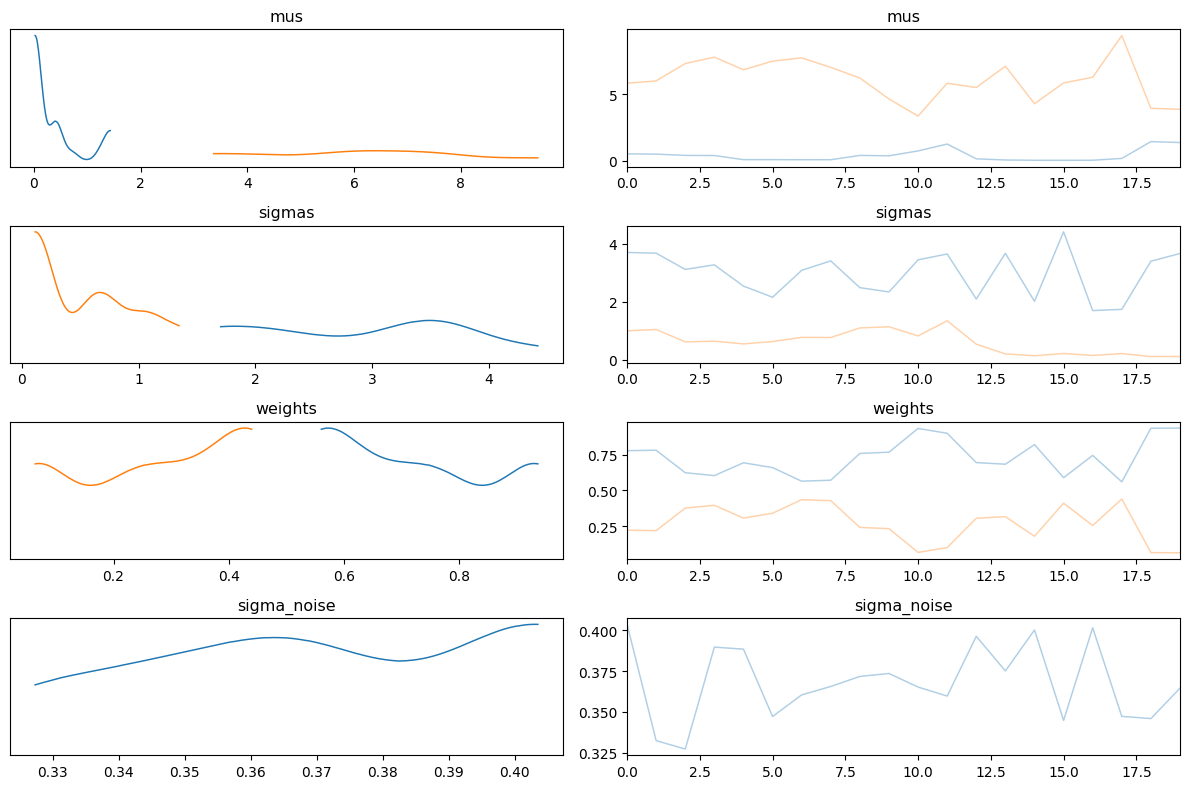

In [183]:
# Minimal fix for your error: make `sigma_noise` broadcast over time in the likelihood.
# The issue arises in Predictive where g_predicted has shape (batch, T)
# while sigma_noise has shape (batch,). Expanding sigma_noise to (batch, 1)
# resolves the mismatch.

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

from jax.scipy.special import erfc as jax_erfc

import numpyro
import numpyro.distributions as dist
from numpyro import deterministic, factor, sample
from numpyro.infer import MCMC, NUTS, Predictive

from scipy.special import erfc as np_erfc


# -----------------------------
# 1) JAX forward model (robust broadcasting)
# -----------------------------

def laplace_transform_jax(mus, sigmas, weights, t):
    t = jnp.asarray(t)             # (T,)
    mus = jnp.asarray(mus)         # (..., K)
    sigmas = jnp.asarray(sigmas)   # (..., K)
    weights = jnp.asarray(weights) # (..., K)

    lead_rank = mus.ndim - 1
    t_bt = jnp.reshape(t, (1,) * lead_rank + (t.shape[0],))  # (..., T)
    t_bt = t_bt[..., None, :]                                # (..., 1, T)

    mus_bt = mus[..., None]           # (..., K, 1)
    sigmas_bt = sigmas[..., None]     # (..., K, 1)
    weights_bt = weights[..., None]   # (..., K, 1)

    arg = (sigmas_bt**2 * t_bt - mus_bt) / (jnp.sqrt(2.0) * sigmas_bt)
    comp = 0.5 * jnp.exp(0.5 * (sigmas_bt**2) * (t_bt**2) - mus_bt * t_bt) * jax_erfc(arg)
    return jnp.sum(weights_bt * comp, axis=-2)  # (..., T)

# -----------------------------
# 3) NumPyro model
# -----------------------------

def model(t, y=None, K=2):
    weights = sample("weights", dist.Dirichlet(jnp.ones(K)))
    mus = sample("mus", dist.HalfNormal(2.0).expand([K]).to_event(1))
    sigmas = sample("sigmas", dist.HalfNormal(1.0).expand([K]).to_event(1))
    sigma_noise = sample("sigma_noise", dist.HalfNormal(0.1))  # scalar per draw

    # Ordering constraint on mus (last axis)
    ok = jnp.all(jnp.diff(mus, axis=-1) > 0.0, axis=-1)
    factor("order_mus_factor", jnp.where(ok, 0.0, -jnp.inf))

    # Forward model
    g_predicted = laplace_transform_jax(mus, sigmas, weights, t)  # (..., T)
    deterministic("g_predicted", g_predicted)

    # Likelihood (FIX HERE): broadcast sigma over time dimension
    # In Predictive, g_predicted has shape (batch, T) while sigma_noise has (batch,)
    # Expanding with [..., None] makes it (batch, 1) -> broadcasts to (batch, T)
    sample("Y_obs", dist.Normal(g_predicted, sigma_noise[..., None]), obs=y)

# -----------------------------
# 4) Sampling & Predictive
# -----------------------------
K = 2
angle_idx = 10

# scaling = diffusion_coef(1) * (q**2)[angle_idx] * 1e7
observed_data = mix_1[angle_idx]
t_data_jnp = jnp.asarray(t_data_np)

rng_key = jax.random.PRNGKey(42)

nuts = NUTS(model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_warmup=10, num_samples=20, num_chains=1)



mcmc.run(rng_key, t=t_data_jnp, y=jnp.asarray(observed_data), K=K)

posterior_samples = mcmc.get_samples(group_by_chain=True)  # (C, D, ...)

pred = Predictive(model, posterior_samples=posterior_samples, return_sites=["Y_obs", "g_predicted"]) 
ppc = pred(rng_key, t=t_data_jnp, y=None, K=K)  # Works now

# Shapes convenience check
print({k: np.asarray(v).shape for k, v in ppc.items()})  # {'Y_obs': (C, D, T), 'g_predicted': (C, D, T)}

# Build InferenceData
coords = {"time": t_data_jnp, "component": np.arange(K)}
dims = {"Y_obs": ["time"], "g_predicted": ["time"], "mus": ["component"], "sigmas": ["component"], "weights": ["component"]}

idata = az.from_numpyro(
    mcmc,
    posterior_predictive={"Y_obs": ppc["Y_obs"]},
    predictions={"g_predicted": ppc["g_predicted"]},
    coords=coords,
    dims=dims,
)

# Quick viz
az.plot_trace(idata, var_names=["mus", "sigmas", "weights", "sigma_noise"])
plt.tight_layout(); plt.show()


In [ ]:
# t_data_jnp * 1e7
angle_idx = 10
t_index = jnp.arange(60, 70)
# jnp.exp(-(diffusion_coef(200e-9) * (q**2)[angle_idx] * t[t_index]))
mix_1[angle_idx, t_index]


Array([0.9313392 , 0.926979  , 0.9230393 , 0.9145983 , 0.906442  ,
       0.8976778 , 0.88987005, 0.8820051 , 0.87413436, 0.86622125],      dtype=float32)

In [100]:
diffusion_coef(200e-9) * (q**2)[angle_idx]

Array(353.21835, dtype=float32)

In [94]:
jnp.exp(-(diffusion_coef(200e-9) * (q**2)[angle_idx] * t[t_index]))


Array([0.9688472 , 0.9666595 , 0.96447676, 0.960126  , 0.9557949 ,
       0.9514833 , 0.9471912 , 0.9429184 , 0.9386649 , 0.9344306 ],      dtype=float32)

In [107]:
jnp.exp(-(diffusion_coef(200) * (q**2)[angle_idx] * t[t_index] * 1e9))


Array([0.9688472 , 0.9666595 , 0.96447676, 0.960126  , 0.9557949 ,
       0.9514833 , 0.9471912 , 0.9429184 , 0.9386649 , 0.9344306 ],      dtype=float32)

In [114]:
scaling = diffusion_coef(1) * (q**2)[angle_idx] * 1e9

jnp.exp(-((1/200) * t[t_index] * scaling))


Array([0.9688472 , 0.9666595 , 0.96447676, 0.960126  , 0.9557949 ,
       0.9514833 , 0.9471912 , 0.9429184 , 0.9386649 , 0.9344306 ],      dtype=float32)

In [116]:
scaling = diffusion_coef(1) * (q**2)[angle_idx] * 1e7

jnp.exp(-((1/2) * t[t_index] * scaling))


Array([0.9688472 , 0.9666595 , 0.96447676, 0.960126  , 0.9557949 ,
       0.9514833 , 0.9471912 , 0.9429184 , 0.9386649 , 0.9344306 ],      dtype=float32)

In [ ]:
# --- Imports ---
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.scipy as jsp

import numpyro
import numpyro.distributions as dist
from numpyro import deterministic, factor, sample
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.distributions import transforms

# -----------------------------
# 0) Constants
# -----------------------------
SCALING_CONST = 2.45e-12  # from your reference model


# -----------------------------
# 1) Reference forward model (MDLS)
#     Produces g2_minus1(q, t) with shape (N_q, T)
# -----------------------------
def get_g1(t, nk, a, c):
    # t: scalar (vmap over time will vectorize)
    b = a**2 / 2.0
    d = jnp.sqrt(2.0)
    s_pi = jnp.sqrt(jnp.pi)
    x = (-a + c * t) / d
    # erfc(x) * exp(x^2) for numerical stability vs 1/(x*sqrt(pi)) tail
    y = jnp.where(
        x >= 5.0,
        1.0 / (x * s_pi),
        jsp.special.erfc(x) * jnp.exp(x**2),
    )
    e = (nk / 2.0) * jnp.exp(-b)
    return e * y  # scalar

# vectorize along time
all_g1 = jax.vmap(get_g1, in_axes=(0, None, None, None))  # (T,), -, -, - -> (T,)

def source3_1(t, q, amp, mu, sig):
    # amp, mu, sig are per-component (scalars here; vmap over components later)
    nk = amp
    sig = sig * SCALING_CONST
    mu  = mu  * SCALING_CONST
    a = mu / sig
    c = q**2 * sig
    return all_g1(t, nk, a, c)  # (T,)

# vmap over mixture components (K)
by_Xs1 = jax.vmap(source3_1, in_axes=(None, None, 0, 0, 0))  # -> (K, T)

# vmap over angles (N_q)
source_matrix1 = jax.vmap(by_Xs1, in_axes=(None, 0, None, None, None))  # -> (N_q, K, T)

def g1_matrix(q, t, amp, mu, sig):
    # q: (N_q,), t: (T,), amp/mu/sig: (K,)
    full = source_matrix1(t, q, amp, mu, sig)  # (N_q, K, T)
    return jnp.sum(full, axis=1)               # (N_q, T)

def g2_minus1_matrix(q, t, amp, mu, sig, beta):
    g1 = g1_matrix(q, t, amp, mu, sig)         # (N_q, T)
    return beta * g1**2                         # (N_q, T)


# -----------------------------
# 2) NumPyro model for MDLS g2-1
# -----------------------------

def model_mdls(t, q, y=None, K=2):
    """
    t: (T,)
    q: (N_q,)
    y: (N_q, T) for g2 - 1
    """
    # Component params
    amp = sample("amp", dist.HalfNormal(1.0).expand([K]).to_event(1))

    # (FIX) Sample ordered mu directly; removes need for `factor` with -inf.
    mu = sample(
        "mu",
        dist.TransformedDistribution(
            dist.HalfNormal(2.0).expand([K]).to_event(1),
            transforms.OrderedTransform()
        ),
    )

    sig = sample("sig", dist.HalfNormal(1.0).expand([K]).to_event(1))

    # Coherence factor and noise
    beta = sample("beta", dist.Beta(2.0, 2.0))
    sigma_noise = sample("sigma_noise", dist.HalfNormal(0.05))  # scalar; broadcasts

    # Forward model -> (N_q, T)
    g2m1 = g2_minus1_matrix(q, t, amp, mu, sig, beta)
    deterministic("g2m1_predicted", g2m1)

    # Likelihood: broadcast sigma over angle × time
    sample("Y_obs", dist.Normal(g2m1, sigma_noise[..., None, None]), obs=y)

# -----------------------------
# 3) Sampling & posterior predictive
# -----------------------------
K = 2

# Provide your data:
# - q_data_np: 1D array of length N_q (angles), e.g. scattering vectors
# - t_data_np: 1D array of length T (time)
# - g2m1_data: (N_q, T) array with g2 - 1 (if you have raw g2, use g2 - 1.0)

# q_data_jnp = jnp.asarray(q_data_np)              # shape (N_q,)
# t_data_jnp = jnp.asarray(t_data_np)              # shape (T,)
# y_obs_jnp  = jnp.asarray(g2m1_data)              # shape (N_q, T)
q_data_jnp = jnp.asarray(q)              # shape (N_q,)
t_data_jnp = jnp.asarray(t)              # shape (T,)
y_obs_jnp  = jnp.asarray(mix_1)              # shape (N_q, T)

rng_key = jax.random.PRNGKey(42)

nuts = NUTS(model_mdls, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=1)

mcmc.run(rng_key, t=t_data_jnp, q=q_data_jnp, y=y_obs_jnp, K=K)

posterior_samples = mcmc.get_samples(group_by_chain=True)

# Posterior predictive (angles × time)
pred = Predictive(model_mdls, posterior_samples=posterior_samples,
                  return_sites=["Y_obs", "g2m1_predicted"])
ppc = pred(rng_key, t=t_data_jnp, q=q_data_jnp, y=None, K=K)

# Check shapes: {'Y_obs': (chains, draws, N_q, T), 'g2m1_predicted': same}
print({k: np.asarray(v).shape for k, v in ppc.items()})

# -----------------------------
# 4) ArviZ InferenceData + quick viz
# -----------------------------
coords = {
    "time":   np.asarray(t_data_jnp),
    "angle":  np.asarray(q_data_jnp),
    "component": np.arange(K),
}
dims = {
    "Y_obs": ["angle", "time"],
    "g2m1_predicted": ["angle", "time"],
    "amp": ["component"],
    "mu":  ["component"],
    "sig": ["component"],
}

idata = az.from_numpyro(
    mcmc,
    posterior_predictive={"Y_obs": ppc["Y_obs"]},
    predictions={"g2m1_predicted": ppc["g2m1_predicted"]},
    coords=coords,
    dims=dims,
)

az.plot_trace(idata, var_names=["amp", "mu", "sig", "beta", "sigma_noise"])
plt.tight_layout(); plt.show()


RuntimeError: Cannot find valid initial parameters. Please check your model again.

$\chi^2$

Array([9.99870002e-01, 9.99805093e-01, 9.99740064e-01, 9.99675095e-01,
       9.99610066e-01, 9.99545157e-01, 9.99480188e-01, 9.99415219e-01,
       9.99350309e-01, 9.99285340e-01, 9.99220431e-01, 9.99155402e-01,
       9.99090552e-01, 9.99025583e-01, 9.98960614e-01, 9.98830855e-01,
       9.98701096e-01, 9.98571217e-01, 9.98441458e-01, 9.98311698e-01,
       9.98181939e-01, 9.98052299e-01, 9.97922480e-01, 9.97663140e-01,
       9.97403920e-01, 9.97144699e-01, 9.96885538e-01, 9.96626437e-01,
       9.96367514e-01, 9.96108532e-01, 9.95849669e-01, 9.95332241e-01,
       9.94814992e-01, 9.94298100e-01, 9.93781507e-01, 9.93265092e-01,
       9.92749095e-01, 9.92233276e-01, 9.91717815e-01, 9.90687728e-01,
       9.89658773e-01, 9.88630950e-01, 9.87604260e-01, 9.86578703e-01,
       9.85554338e-01, 9.84531045e-01, 9.83508945e-01, 9.81468081e-01,
       9.79431689e-01, 9.77399945e-01, 9.75372612e-01, 9.73349810e-01,
       9.71331537e-01, 9.69317615e-01, 9.67308283e-01, 9.63302851e-01,
      

In [177]:
scaling = diffusion_coef(1) * (q**2)[angle_idx] * 1e7
jnp.sqrt(jnp.sum((1*jnp.exp(-((1/1) * t * scaling)) + 0.0*jnp.exp(-((1/5) * t * scaling))) - mix_1[angle_idx])**2)
# jnp.sqrt(jnp.sum((jnp.exp(-((1/1) * t * scaling)) - observations_200[angle_idx])**2))



Array(0.07785209, dtype=float32)

In [182]:
diffusion_coef(1)

2.4525776730461077e-19

In [158]:
jnp.sqrt(jnp.sum((jnp.exp(-(diffusion_coef(500e-9) * (q**2)[angle_idx] * t)) - observations_1000[angle_idx])**2))


Array(0.75310075, dtype=float32)

In [ ]:
jnp.sqrt(jnp.sum((jnp.exp(-(diffusion_coef(500e-9) * (q**2)[angle_idx] * t)) - observations_1000[angle_idx])**2))


In [ ]:
"""
NumPyro model for MDLS g2 data: uses g2_minus1_matrix(q, t, amp, mu, sig, beta)
with robust batching so Predictive works with posterior samples (chains, draws,...).

Shapes
------
q: (Q,)
t: (T,)
amp, mu, sig: (..., K)
beta: (...,)
Returns g2_minus1: (..., Q, T)

Plug in your real data by setting `q_data_np`, `t_data_np`, and `g2_minus1_obs`.
Alternatively, run the synthetic block to generate example data.
"""

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax.scipy.special import erfc as jax_erfc

import numpyro
import numpyro.distributions as dist
from numpyro import deterministic, factor, sample
from numpyro.infer import MCMC, NUTS, Predictive

from scipy.special import erfc as np_erfc

# Optional numerical tweak
# jax.config.update("jax_enable_x64", True)

SCALING_CONST = 2.45e-12

# -----------------------------
# 1) MDLS forward model (batched)
# -----------------------------

def get_g1_batched(t, nk, a, c):
    """Vectorized version of your `get_g1` that supports batch dims.

    Parameters
    ----------
    t : (T,)
    nk : (..., K)
    a  : (..., K)
    c  : (..., K, Q)

    Returns
    -------
    (..., K, Q, T)
    """
    d = jnp.sqrt(2.0)
    s_pi = jnp.sqrt(jnp.pi)

    # Shapes to broadcast: (..., K, Q, T)
    t_bt = t[None, None, None, :]  # (1,1,1,T)

    a_bt = a[..., :, None, None]   # (..., K, 1, 1)
    c_bt = c[..., :, :, None]      # (..., K, Q, 1)
    nk_bt = nk[..., :, None, None] # (..., K, 1, 1)

    b = (a_bt ** 2) / 2.0          # (..., K, 1, 1)
    x = (-a_bt + c_bt * t_bt) / d   # (..., K, Q, T)

    # piecewise y
    y = jnp.where(
        x >= 5.0,
        1.0 / (x * s_pi),
        jax_erfc(x) * jnp.exp(x ** 2),
    )

    e = (nk_bt / 2.0) * jnp.exp(-b)     # (..., K, 1, 1)
    return e * y                        # (..., K, Q, T)


def g2_minus1_batched(q, t, amp, mu, sig, beta):
    """Compute g2-1 with batching over leading dims and mixture components.

    Parameters
    ----------
    q : (Q,)
    t : (T,)
    amp, mu, sig : (..., K)
    beta : (...,)

    Returns
    -------
    g2_minus1 : (..., Q, T)
    """
    q = jnp.asarray(q)
    t = jnp.asarray(t)
    amp = jnp.asarray(amp)
    mu = jnp.asarray(mu)
    sig = jnp.asarray(sig)
    beta = jnp.asarray(beta)

    # Scale physical parameters as in your model
    sig_s = sig * SCALING_CONST      # (..., K)
    mu_s  = mu  * SCALING_CONST      # (..., K)

    a = mu_s / sig_s                 # (..., K)

    # c depends on q and sig_s: c = q^2 * sig_s
    # Broadcast to (..., K, Q)
    c = sig_s[..., :, None] * (q[None, None, :] ** 2)

    # g1 per component and q: (..., K, Q, T)
    g1_kqt = get_g1_batched(t, amp, a, c)

    # Sum over components K -> (..., Q, T)
    g1_qt = jnp.sum(g1_kqt, axis=-3)

    # g2 - 1 = beta * g1^2 ; expand beta over Q,T
    g2m1 = beta[..., None, None] * (g1_qt ** 2)
    return g2m1  # (..., Q, T)

# -----------------------------
# 2) Synthetic data (or plug in real data)
# -----------------------------
# Example grids
Q = 6
T = 120
q_data_np = np.linspace(1e6, 5e6, Q)   # example q values (units depend on setup)
t_data_np = np.geomspace(1e-6, 1e-1, T)

# True params
K = 2
TRUE_AMP = np.array([0.8, 0.4])
TRUE_MU  = np.array([2.0, 12.0])
TRUE_SIG = np.array([0.5, 3.0])
TRUE_BETA = 0.6
TRUE_NOISE_SD = 0.01

# Generate synthetic g2-1
with np.errstate(over='ignore'):
    # Build a NumPy version for data gen
    def g2_minus1_numpy(q, t, amp, mu, sig, beta):
        # at the start of g2_minus1_batched(...)
        q = jnp.ravel(jnp.asarray(q))   # (Q,)
        t = jnp.ravel(jnp.asarray(t))   # (T,)
        q = np.asarray(q); t = np.asarray(t)
        amp = np.asarray(amp); mu = np.asarray(mu); sig = np.asarray(sig)
        sig_s = sig * SCALING_CONST
        mu_s = mu * SCALING_CONST
        a = mu_s / sig_s
        c = sig_s[:, None] * (q[None, :] ** 2)  # (K,Q)
        d = np.sqrt(2.0)
        s_pi = np.sqrt(np.pi)
        # shapes (K,Q,T)
        x = (-a[:, None, None] + c[:, :, None] * t[None, None, :]) / d
        y = np.where(x >= 5.0, 1.0 / (x * s_pi), np_erfc(x) * np.exp(x ** 2))
        e = (amp[:, None, None] / 2.0) * np.exp(-(a[:, None, None] ** 2) / 2.0)
        g1 = np.sum(e * y, axis=0)  # (Q,T)
        return beta * g1 ** 2

    g2m1_true = g2_minus1_numpy(q_data_np, t_data_np, TRUE_AMP, TRUE_MU, TRUE_SIG, TRUE_BETA)

rng = np.random.default_rng(123)
g2_minus1_obs = g2m1_true + rng.normal(0, TRUE_NOISE_SD, size=g2m1_true.shape)

# -----------------------------
# 3) NumPyro model (MDLS g2)
# -----------------------------

def model(q, t, Y=None, K=2):
    # Priors
    amp = sample("amp", dist.HalfNormal(1.0).expand([K]).to_event(1))
    mu  = sample("mu",  dist.Normal(5.0, 10.0).expand([K]).to_event(1))
    sig = sample("sig", dist.HalfNormal(5.0).expand([K]).to_event(1))
    beta = sample("beta", dist.Beta(2.0, 2.0))
    sigma_noise = sample("sigma_noise", dist.HalfNormal(0.1))

    # Optional identifiability (increasing mu)
    ok = jnp.all(jnp.diff(mu, axis=-1) > 0.0, axis=-1)
    factor("order_mu_factor", jnp.where(ok, 0.0, -jnp.inf))

    # Forward model -> (..., Q, T) here just (Q,T)
    g2m1 = g2_minus1_batched(q, t, amp, mu, sig, beta)
    deterministic("g2_minus1_pred", g2m1)

    # Likelihood (broadcast sigma over Q,T)
    sample("Y_obs", dist.Normal(g2m1, sigma_noise[..., None, None]), obs=Y)

# -----------------------------
# 4) Inference
# -----------------------------
q_data_np  = np.asarray(q_data_np).reshape(-1)
t_data_np  = np.asarray(t_data_np).reshape(-1)
q_data_jnp = jnp.asarray(q_data_np)
t_data_jnp = jnp.asarray(t_data_np)
rng_key = jax.random.PRNGKey(0)

nuts = NUTS(model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=2)
mcmc.run(rng_key, q=q_data_jnp, t=t_data_jnp, Y=jnp.asarray(g2_minus1_obs), K=K)
mcmc.print_summary()

# Posterior predictive
posterior_samples = mcmc.get_samples(group_by_chain=True)
pred = Predictive(model, posterior_samples=posterior_samples, return_sites=["Y_obs", "g2_minus1_pred"]) 
ppc = pred(rng_key, q=q_data_jnp, t=t_data_jnp, Y=None, K=K)

# -----------------------------
# 5) ArviZ & plots
# -----------------------------
coords = {"q": q_data_np, "time": t_data_np, "component": np.arange(K)}
dims = {
    "Y_obs": ["q", "time"],
    "g2_minus1_pred": ["q", "time"],
    "amp": ["component"],
    "mu": ["component"],
    "sig": ["component"],
}

idata = az.from_numpyro(
    mcmc,
    posterior_predictive={"Y_obs": ppc["Y_obs"]},
    predictions={"g2_minus1_pred": ppc["g2_minus1_pred"]},
    coords=coords,
    dims=dims,
)

print("\n--- Model Summary ---")
print(az.summary(idata, var_names=["amp", "mu", "sig", "beta", "sigma_noise"]))

# Quick visualization for one q-slice (e.g., q index 0)
q_idx = 0
post_y = np.asarray(ppc["Y_obs"])  # (C,D,Q,T)
post_y_flat = post_y.reshape(-1, post_y.shape[-2], post_y.shape[-1])  # (S, Q, T)
post_slice = post_y_flat[:, q_idx, :]
q05, q50, q95 = np.percentile(post_slice, [5, 50, 95], axis=0)

plt.figure(figsize=(11, 6))
plt.fill_between(t_data_np, q05, q95, alpha=0.2, label="90% pred. interval")
plt.plot(t_data_np, q50, lw=2, label="Posterior median")
plt.scatter(t_data_np, g2_minus1_obs[q_idx], s=12, alpha=0.6, label="Observed (q[0])")
plt.xscale('log')
plt.xlabel('Time (t)')
plt.ylabel('g2 - 1')
plt.title('MDLS g2 fit for one q-bin')
plt.legend(); plt.grid(True, ls='--', alpha=0.5); plt.show()


/tmp/ipykernel_26202/3546424687.py:197: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=2)
sample: 100%|██████████| 3000/3000 [02:09<00:00, 23.18it/s, 1023 steps of size 1.25e-03. acc. prob=0.94]



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
       amp[0]      1.83      0.87      2.06      0.77      2.83      1.02      7.05
       amp[1]      0.68      0.33      0.84      0.29      1.05      1.03      5.90
         beta      0.71      0.20      0.85      0.36      0.87      1.51      1.66
        mu[0]      0.92      1.29      0.69     -0.51      2.40      1.01      9.73
        mu[1]      8.93      4.66      7.86      4.13     14.60      1.03      5.84
       sig[0]      0.57      0.57      0.16      0.13      1.46      1.55      1.68
       sig[1]      2.22      0.49      2.45      1.24      2.84      4.19      1.19
  sigma_noise      0.01      0.00      0.01      0.01      0.02      1.03      8.94

Number of divergences: 2244


CoordinateValidationError: conflicting sizes for dimension 'q': length 1 on the data but length 6 on coordinate 'q'

In [25]:
"""
MDLS g₂ model in NumPyro — complete, runnable script
- Stable special fn: uses erfcx(x) instead of erfc(x)*exp(x**2)
- Ordered means without potentials: mu = sort(mu_raw)
- Broadcast‑safe Predictive: sigma_noise[..., None, None]
- ArviZ dims/coords matched to data; q,t enforced 1‑D

Swap in your real (q, t, g2_minus1_obs) in the DATA section.
"""

# ====== IMPORTS ======
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax.scipy.special import erfcx as jax_erfcx

import numpyro
import numpyro.distributions as dist
from numpyro import deterministic, sample
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.initialization import init_to_median

from scipy.special import erfcx as np_erfcx

# Optional: double precision
# jax.config.update("jax_enable_x64", True)

# ====== CONSTANTS ======
SCALING_CONST = 2.45e-12

# ====== FORWARD MODEL (batched + stable) ======

def get_g1_batched_stable(t, nk, a, c):
    """Compute g1 with numerically stable erfcx and broadcasting.
    t : (T,)
    nk : (..., K)
    a  : (..., K)
    c  : (..., K, Q)
    returns: (..., K, Q, T)
    """
    # target shape: (..., K, Q, T)
    t_bt = t[None, None, None, :]        # (1,1,1,T)
    a_bt = a[..., :, None, None]         # (...,K,1,1)
    c_bt = c[..., :, :, None]            # (...,K,Q,1)
    nk_bt = nk[..., :, None, None]       # (...,K,1,1)

    d = jnp.sqrt(2.0)
    b = (a_bt ** 2) / 2.0
    x = (-a_bt + c_bt * t_bt) / d        # (...,K,Q,T)

    # erfcx(x) = exp(x^2) * erfc(x) — stable across ℝ
    y = jax_erfcx(x)
    e = (nk_bt / 2.0) * jnp.exp(-b)
    return e * y                         # (...,K,Q,T)


def g2_minus1_batched(q, t, amp, mu, sig, beta):
    """Compute g₂ − 1 with full batching over leading dims/components.
    q : (Q,)
    t : (T,)
    amp, mu, sig : (..., K)
    beta : (...,)
    returns: (..., Q, T)
    """
    # Enforce 1‑D for q,t to avoid accidental singleton event dims
    q = jnp.ravel(jnp.asarray(q))            # (Q,)
    t = jnp.ravel(jnp.asarray(t))            # (T,)
    amp = jnp.asarray(amp)
    mu  = jnp.asarray(mu)
    sig = jnp.asarray(sig)
    beta = jnp.asarray(beta)

    sig_s = sig * SCALING_CONST             # (...,K)
    mu_s  = mu  * SCALING_CONST             # (...,K)
    a = mu_s / sig_s                        # (...,K)

    # c = q^2 * sig_s → (...,K,Q)
    c = sig_s[..., :, None] * (q[None, None, :] ** 2)

    g1_kqt = get_g1_batched_stable(t, amp, a, c)  # (...,K,Q,T)
    g1_qt = jnp.sum(g1_kqt, axis=-3)              # sum over K → (...,Q,T)
    return beta[..., None, None] * (g1_qt ** 2)   # (...,Q,T)

# ====== MODEL ======

def model(q, t, Y=None, K=2):
    # Positive amplitudes / widths
    amp = sample("amp", dist.HalfNormal(1.0).expand([K]).to_event(1))
    sig = sample("sig", dist.HalfNormal(5.0).expand([K]).to_event(1))

    # Ordered means via sorting (no hard potential at init time)
    mu_raw = sample("mu_raw", dist.Normal(5.0, 10.0).expand([K]).to_event(1))
    mu = deterministic("mu", jnp.sort(mu_raw, axis=-1))

    beta = sample("beta", dist.Beta(2.0, 2.0))
    sigma_noise = sample("sigma_noise", dist.HalfNormal(0.1))

    g2m1 = g2_minus1_batched(q, t, amp, mu, sig, beta)
    deterministic("g2_minus1_pred", g2m1)

    # Broadcast sigma over (Q,T)
    sample("Y_obs", dist.Normal(g2m1, sigma_noise[..., None, None]), obs=Y)

# ====== DATA (replace with your real data) ======
# Example grids
Q = 6
T = 120
q_data_np = np.linspace(1e6, 5e6, Q)          # shape (Q,)
t_data_np = np.geomspace(1e-6, 1e-1, T)       # shape (T,)

# True params for synthetic example
K = 2
TRUE_AMP  = np.array([0.8, 0.4])
TRUE_MU   = np.array([2.0, 12.0])
TRUE_SIG  = np.array([0.5, 3.0])
TRUE_BETA = 0.6
TRUE_NOISE_SD = 0.01

# Synthetic generator (NumPy, uses erfcx for stability)
def g2_minus1_numpy(q, t, amp, mu, sig, beta):
    q = np.asarray(q); t = np.asarray(t)
    amp = np.asarray(amp); mu = np.asarray(mu); sig = np.asarray(sig)
    sig_s = sig * SCALING_CONST
    mu_s  = mu  * SCALING_CONST
    a = mu_s / sig_s
    c = sig_s[:, None] * (q[None, :] ** 2)  # (K,Q)
    d = np.sqrt(2.0)
    x = (-a[:, None, None] + c[:, :, None] * t[None, None, :]) / d
    y = np_erfcx(x)
    e = (amp[:, None, None] / 2.0) * np.exp(-(a[:, None, None] ** 2) / 2.0)
    g1 = np.sum(e * y, axis=0)  # (Q,T)
    return beta * g1 ** 2

# Create synthetic observations
rng = np.random.default_rng(123)
true_g2m1 = g2_minus1_numpy(q_data_np, t_data_np, TRUE_AMP, TRUE_MU, TRUE_SIG, TRUE_BETA)
obs_g2m1 = true_g2m1 + rng.normal(0, TRUE_NOISE_SD, size=true_g2m1.shape)

# If using real data, set:
# q_data_np = your_q_vector (shape (Q,))
# t_data_np = your_time_vector (shape (T,))
# obs_g2m1  = your_observed_g2_minus1 (shape (Q,T))
# K = number_of_components

# ====== INFERENCE ======
q_data_np = np.asarray(q_data_np).reshape(-1)
t_data_np = np.asarray(t_data_np).reshape(-1)
q_data_jnp = jnp.asarray(q_data_np)
t_data_jnp = jnp.asarray(t_data_np)

nuts = NUTS(model, target_accept_prob=0.9, init_strategy=init_to_median())
mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=2)
mcmc.run(jax.random.PRNGKey(0), q=q_data_jnp, t=t_data_jnp, Y=jnp.asarray(obs_g2m1), K=K)
mcmc.print_summary()

# ====== POSTERIOR PREDICTIVE ======
posterior_samples = mcmc.get_samples(group_by_chain=True)  # (C,D, ...)
pred = Predictive(model, posterior_samples=posterior_samples, return_sites=["Y_obs", "g2_minus1_pred", "mu"])
ppc = pred(jax.random.PRNGKey(1), q=q_data_jnp, t=t_data_jnp, Y=None, K=K)

# Quick shape sanity check
pp_shapes = {k: np.asarray(v).shape for k, v in ppc.items()}
print("Predictive shapes:", pp_shapes)  # Expect (C,D,Q,T) for both sites

# ====== ARVIZ CONVERSION ======
coords = {"q": q_data_np, "time": t_data_np, "component": np.arange(K)}
dims = {
    "Y_obs": ["q", "time"],
    "g2_minus1_pred": ["q", "time"],
    "amp": ["component"],
    "sig": ["component"],
    "mu_raw": ["component"],
}

idata = az.from_numpyro(
    mcmc,
    posterior_predictive={"Y_obs": ppc["Y_obs"]},
    predictions={"g2_minus1_pred": ppc["g2_minus1_pred"], "mu": ppc["mu"]},
    coords=coords,
    dims=dims,
)

print("\n--- Model Summary ---")
print(az.summary(idata, var_names=["amp", "sig", "mu_raw", "beta", "sigma_noise"]))

# ====== PLOTS ======
# One q-slice
q_idx = 0
post_y = np.asarray(ppc["Y_obs"])  # (C,D,Q,T)
post_flat = post_y.reshape(-1, post_y.shape[-2], post_y.shape[-1])  # (S,Q,T)
sl = post_flat[:, q_idx, :]
q05, q50, q95 = np.percentile(sl, [5, 50, 95], axis=0)

plt.figure(figsize=(10.5, 6))
plt.fill_between(t_data_np, q05, q95, alpha=0.2, label="90% pred. interval")
plt.plot(t_data_np, q50, lw=2, label="Posterior median")
plt.scatter(t_data_np, obs_g2m1[q_idx], s=12, alpha=0.6, label="Observed (q[0])")
plt.xscale('log'); plt.xlabel('Time (t)'); plt.ylabel('g2 - 1')
plt.title('MDLS g₂ fit — NumPyro (stable init)')
plt.legend(); plt.grid(True, ls='--', alpha=0.5); plt.show()


ImportError: cannot import name 'erfcx' from 'jax.scipy.special' (/home/gfertt/.local/lib/python3.10/site-packages/jax/scipy/special.py)